# Снедков Валентин, ЕТ-128, "Качество кластеризации"

## Задание
1. Для набора данных из задания о разделительной кластеризации подберите оптимальное количество кластеров с помощью двух любых приемов из следующего множества: метод локтя, кросс-валидация, силуэтный коэффициент, визуализация матрицы схожести. Постройте диаграммы, подтверждающие полученные результаты.
4. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
- формулировка задания;
- гиперссылка на каталог репозитория с исходными текстами, набором данных и др. сопутствующими материалами;
- рисунки с результатами визуализации;
- пояснения, раскрывающие смысл полученных результатов.

In [ ]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 10)

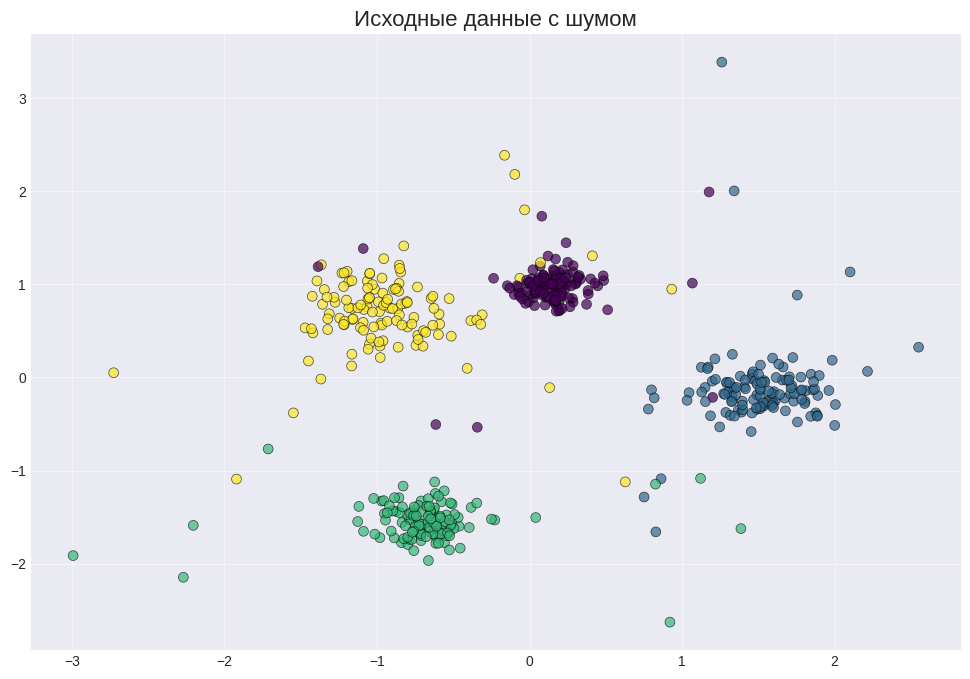

In [ ]:
# Создаем набор данных
# Функция добавления шума
def add_noise(data, noise_percentage, noise_magnitude=0.5):
    data_noisy = data.copy()
    n_points = len(data)
    n_noisy = int(n_points * noise_percentage / 100)

    noisy_indices = np.random.choice(n_points, n_noisy, replace=False)

    for idx in noisy_indices:
        noise = np.random.randn(data.shape[1]) * noise_magnitude
        data_noisy[idx] += noise

    return data_noisy, noisy_indices

np.random.seed(42)
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=[0.8, 1.2, 0.9, 1.5], random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Визуализируем данные
noise_pct = 10
X_noisy, _ = add_noise(X_scaled, noise_pct, noise_magnitude=1.0)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.title('Исходные данные с шумом', fontsize=16)
plt.grid(True, alpha=0.5)

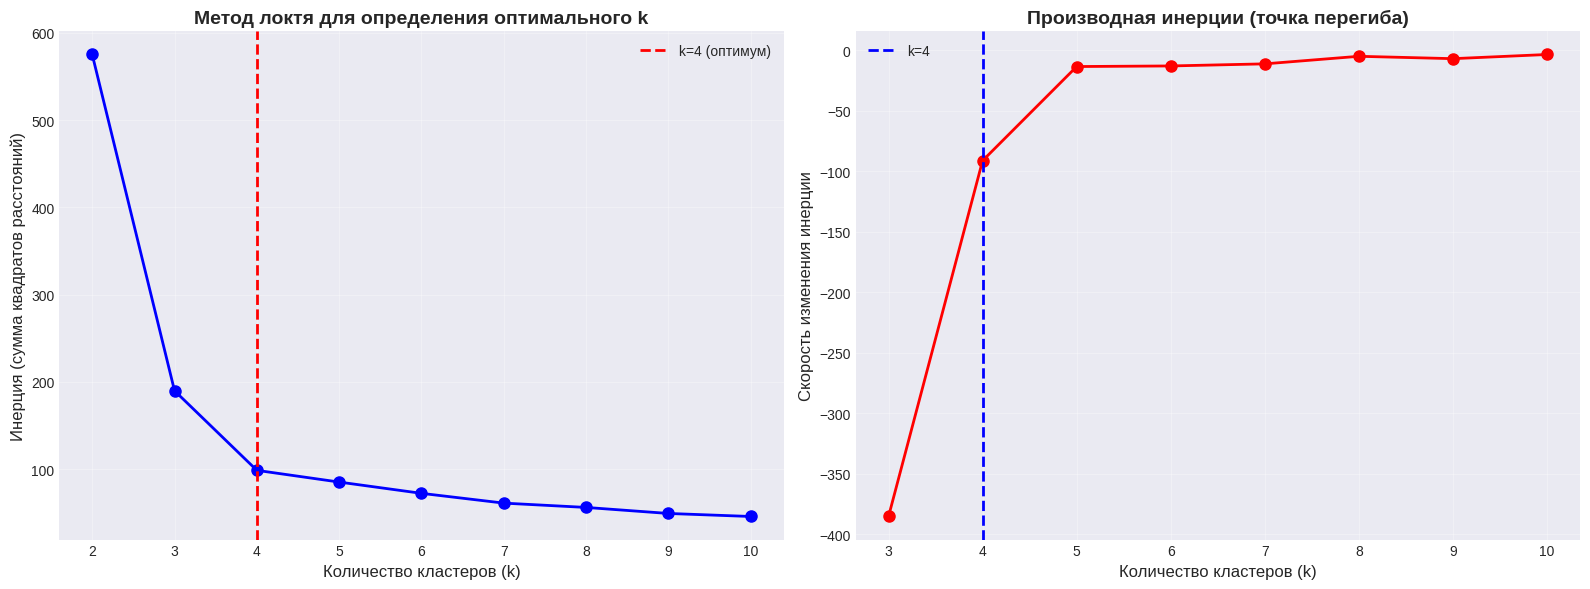

In [ ]:
# Метод локтя (ELBOW)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_noisy)
    inertias.append(kmeans.inertia_)

    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X_noisy, labels))

# Визуализация метода локтя
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=2, label='k=4 (оптимум)')
axes[0].set_xlabel('Количество кластеров (k)', fontsize=12)
axes[0].set_ylabel('Инерция (сумма квадратов расстояний)', fontsize=12)
axes[0].set_title('Метод локтя для определения оптимального k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xticks(K_range)

derivatives = np.diff(inertias)
axes[1].plot(K_range[1:], derivatives, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(x=4, color='blue', linestyle='--', linewidth=2, label='k=4')
axes[1].set_xlabel('Количество кластеров (k)', fontsize=12)
axes[1].set_ylabel('Скорость изменения инерции', fontsize=12)
axes[1].set_title('Производная инерции (точка перегиба)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(K_range[1:])

plt.tight_layout()
plt.show()

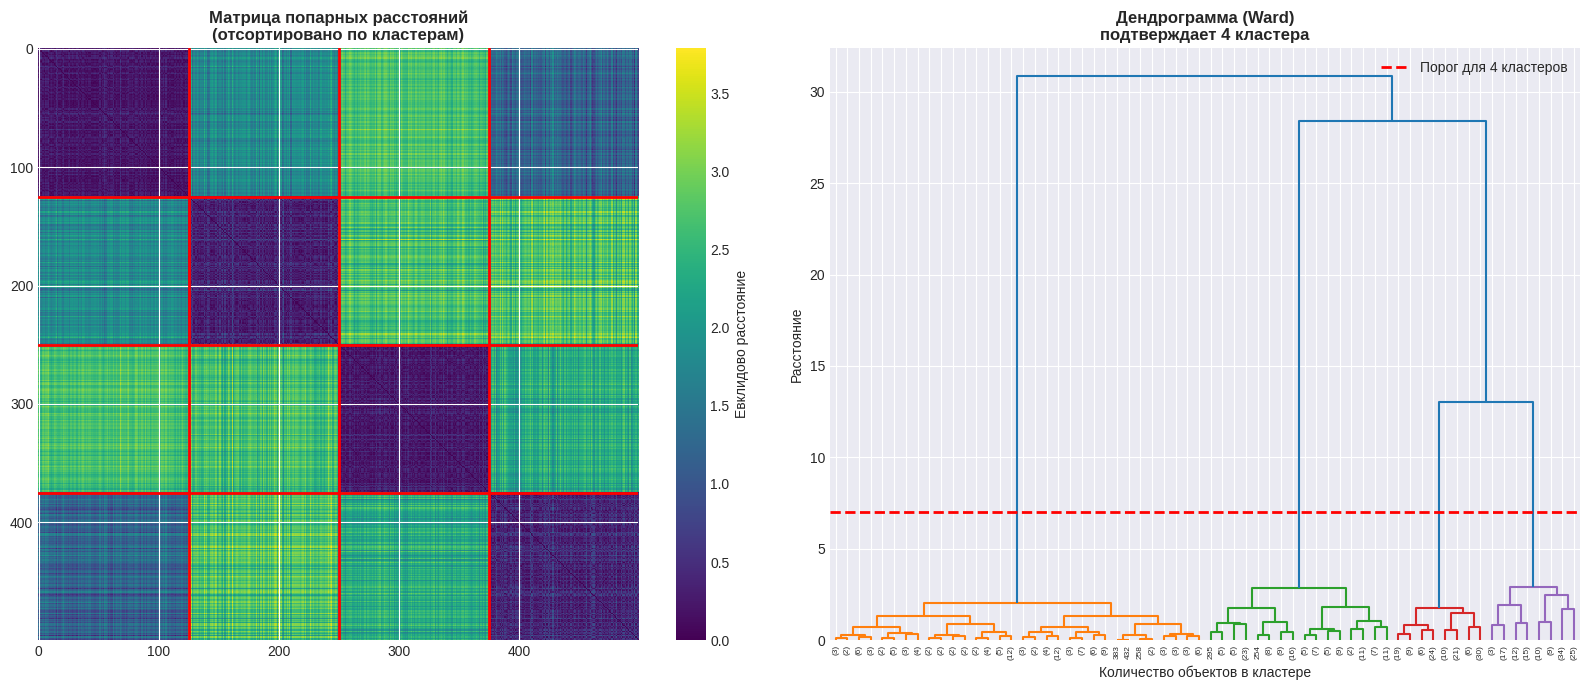

In [ ]:
# Визуализация матрицы схожести
distance_matrix = squareform(pdist(X_scaled))

sort_idx = np.argsort(y_true)
X_sorted = X_scaled[sort_idx]
y_sorted = y_true[sort_idx]
distance_matrix_sorted = squareform(pdist(X_sorted))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Тепловая карта матрицы расстояний
im1 = axes[0].imshow(distance_matrix_sorted, cmap='viridis', aspect='auto', interpolation='nearest')
axes[0].set_title('Матрица попарных расстояний\n(отсортировано по кластерам)', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Евклидово расстояние')

cluster_boundaries = np.cumsum([np.sum(y_true == i) for i in range(4)])
for boundary in cluster_boundaries[:-1]:
    axes[0].axhline(y=boundary, color='red', linewidth=2)
    axes[0].axvline(x=boundary, color='red', linewidth=2)

# Дендрограмма
Z = linkage(X_scaled, method='ward')
axes[1] = plt.subplot(1, 2, 2)
dendrogram(Z, ax=axes[1], truncate_mode='level', p=5, color_threshold=7)
axes[1].set_title('Дендрограмма (Ward)\nподтверждает 4 кластера', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Количество объектов в кластере')
axes[1].set_ylabel('Расстояние')
axes[1].axhline(y=7, color='red', linestyle='--', linewidth=2, label='Порог для 4 кластеров')
axes[1].legend()

plt.tight_layout()
plt.show()